## Visualizing simulated data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget
import seaborn as sns
import pandas as pd

In [2]:
run_file = "/Volumes/researchEXT/O16/nim_paper/run0010_data.npy"
data = np.load(run_file)

In [3]:


for idx in range(4000, 5000):
    label = int(data[idx, -2, 0])
    if label != 3:
        continue
    print(idx)

4087
4210
4227
4231
4237
4310
4379
4396
4399
4441
4462
4608
4654
4684
4717
4739
4787
4804
4834
4837
4849
4913
4938


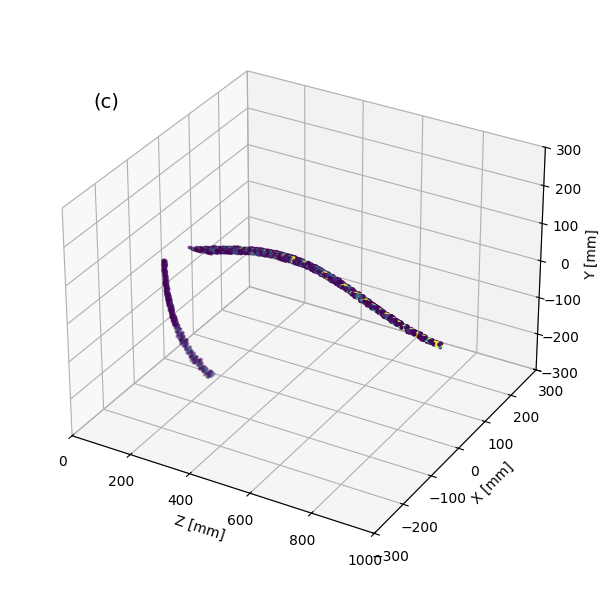

In [4]:
idx = 2
event = data[idx]
label = int(event[-2,0])
points = event[:-2]
valid_points = points[~np.isnan(points[:, 0])]

fig = plt.figure(figsize=(6, 6), layout='constrained')
ax = fig.add_subplot(111, projection='3d')


ax.scatter(valid_points[:, 2], valid_points[:, 0], valid_points[:, 1], c=valid_points[:, 3], s=3)
ax.grid(True)
ax.set_xlim3d(0, 1000)
ax.set_xlabel("Z [mm]")
ax.set_ylim3d(-300, 300)
ax.set_ylabel("X [mm]")

ax.set_zlim3d(-300, 300)
ax.set_zlabel("Y [mm]")

ax.text2D(0.15, 0.85, "(c)", transform=ax.transAxes, fontsize=14, va='top')
# plt.title(f"{label} track event")
# plt.margins(5)
ax.dist=13
ax.set_box_aspect(None, zoom=0.91)
plt.show()

In [5]:
1422, 2, 1742, 1987, 1050

(1422, 2, 1742, 1987, 1050)

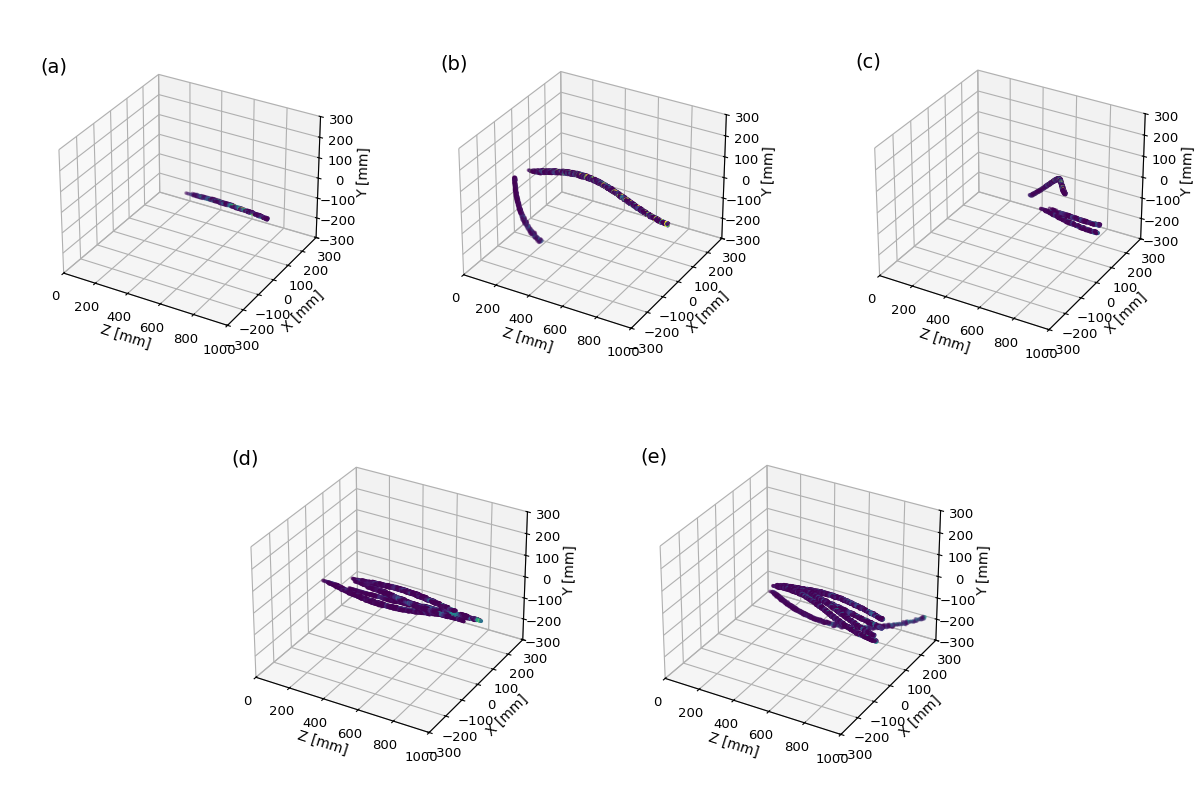

In [6]:
import matplotlib.pyplot as plt
import numpy as np

list_to_visualize = [1422, 2, 4913, 1987, 1050]
labels = ["a", "b", "c", "d", "e"]

fig = plt.figure(figsize=(12, 8), constrained_layout=True)

# 2 rows, 6 columns gives fine control
gs = fig.add_gridspec(2, 6)

axes = []

# Top row: 3 plots, each spans 2 columns
for i in range(3):
    ax = fig.add_subplot(gs[0, 2*i:2*(i+1)], projection='3d')
    axes.append(ax)

# Bottom row: centered 2 plots (leave margins on sides)
axes.append(fig.add_subplot(gs[1, 1:3], projection='3d'))  # left centered
axes.append(fig.add_subplot(gs[1, 3:5], projection='3d'))  # right centered

# Plot
for i, (idx, ax) in enumerate(zip(list_to_visualize, axes)):
    event = data[idx]
    label = int(event[-2, 0])
    points = event[:-2]
    valid_points = points[~np.isnan(points[:, 0])]

    ax.scatter(
        valid_points[:, 2],
        valid_points[:, 0],
        valid_points[:, 1],
        c=valid_points[:, 3],
        s=3
    )

    ax.grid(True)
    ax.set_xlim3d(0, 1000)
    ax.set_xlabel("Z [mm]")
    ax.set_ylim3d(-300, 300)
    ax.set_ylabel("X [mm]")
    ax.set_zlim3d(-300, 300)
    ax.set_zlabel("Y [mm]")
    ax.tick_params(axis='both', which='major', labelsize=9.5)
    
    ax.text2D(0.1, 0.85, f"({labels[i]})",
              transform=ax.transAxes, fontsize=14)

    ax.dist = 13
    ax.set_box_aspect(None, zoom=0.80)

plt.show()

## Adding Noise

3524


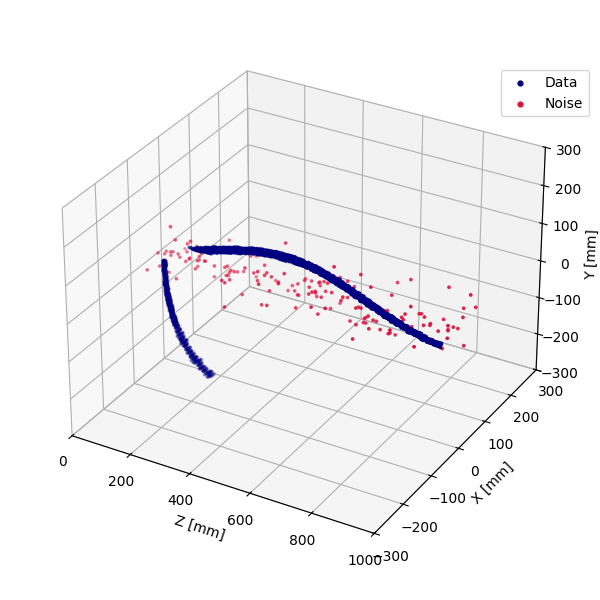

In [7]:
idx = 2
event = data[idx]
label = int(event[-2,0])
points = event[:-2]
valid_points = points[~np.isnan(points[:, 0])]

ratio_noise = 0.05

data_size = int((ratio_noise)*len(valid_points))
            
noise_z = np.random.randint(0,1000,(data_size,1))
r_noise = np.random.normal(0, 50, (data_size,1))

theta_noise = np.random.uniform(0, 2*np.pi, (data_size,1))

noise_x = r_noise * np.cos(theta_noise)
noise_y = r_noise * np.sin(theta_noise)

array_charge = np.zeros((data_size,1))
noise_data = np.concatenate((noise_x,noise_y,noise_z,array_charge),axis=1)
combined_data = np.concatenate((valid_points,noise_data),axis=0)
print(len(combined_data))
fig = plt.figure(figsize=(6, 6), layout='constrained')
ax = fig.add_subplot(111, projection='3d')


ax.scatter(valid_points[:, 2], valid_points[:, 0], valid_points[:, 1], c="navy", s=3, label="Data")
ax.scatter(noise_data[:, 2], noise_data[:, 0], noise_data[:, 1], c="crimson", s=3, label="Noise")
# ax.scatter(combined_data[:, 2], combined_data[:, 0], combined_data[:, 1], s=3, label="combined")

ax.grid(True)
ax.set_xlim3d(0, 1000)
ax.set_xlabel("Z [mm]")
ax.set_ylim3d(-300, 300)
ax.set_ylabel("X [mm]")

ax.set_zlim3d(-300, 300)
ax.set_zlabel("Y [mm]")

# ax.text2D(0.15, 0.85, "(c)", transform=ax.transAxes, fontsize=14, va='top')
# plt.title(f"{label} track event")
# plt.margins(5)
ax.dist=13
ax.set_box_aspect(None, zoom=0.91)
ax.legend(markerscale=2,fontsize=10,loc='upper right', bbox_to_anchor=(1.0, 0.9))
plt.show()

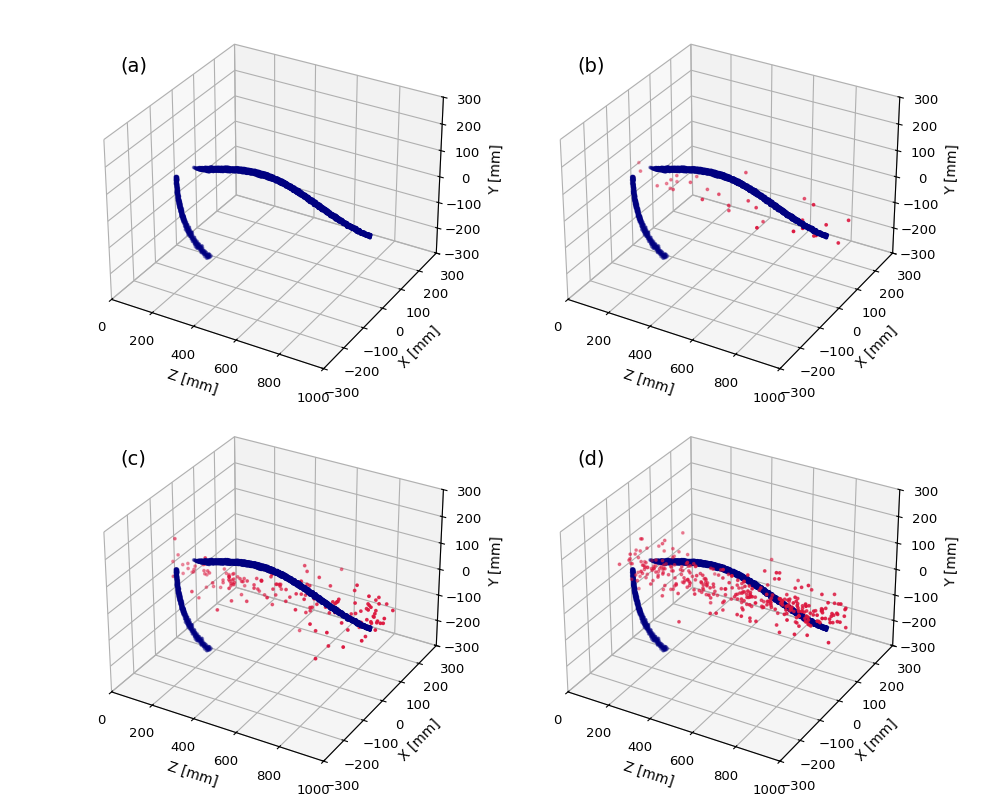

In [8]:
idx = 2
event = data[idx]
label = int(event[-2,0])
points = event[:-2]
valid_points = points[~np.isnan(points[:, 0])]

ratio_noise = [0,0.01,0.05,0.10]
labels = ["a", "b", "c", "d", "e"]

# print(len(combined_data))
# fig = plt.figure(figsize=(6, 6), layout='constrained')
# ax = fig.add_subplot(111, projection='3d')
fig, axes = plt.subplots(2, 2, subplot_kw={'projection': '3d'}, figsize=(10, 8))

# Flatten axes for easy iteration
axes = axes.flatten()

# Plot
for i, (idx, ax) in enumerate(zip(ratio_noise, axes)):
    data_size = int(ratio_noise[i] * len(valid_points))
                
    noise_z = np.random.randint(0, 1000, (data_size, 1))
    r_noise = np.random.normal(0, 50, (data_size, 1))
    theta_noise = np.random.uniform(0, 2*np.pi, (data_size, 1))

    noise_x = r_noise * np.cos(theta_noise)
    noise_y = r_noise * np.sin(theta_noise)

    array_charge = np.zeros((data_size, 1))
    noise_data = np.concatenate((noise_x, noise_y, noise_z, array_charge), axis=1)
    combined_data = np.concatenate((valid_points, noise_data), axis=0)

    ax.scatter(valid_points[:, 2], valid_points[:, 0], valid_points[:, 1],
               c="navy", s=3, label="Data")
    ax.scatter(noise_data[:, 2], noise_data[:, 0], noise_data[:, 1],
               c="crimson", s=3, label="Noise")

    ax.grid(True)
    ax.set_xlim3d(0, 1000)
    ax.set_xlabel("Z [mm]")
    ax.set_ylim3d(-300, 300)
    ax.set_ylabel("X [mm]")
    ax.set_zlim3d(-300, 300)
    ax.set_zlabel("Y [mm]")
    ax.tick_params(axis='both', which='major', labelsize=9.5)
    
    ax.text2D(0.1, 0.85, f"({labels[i]})", transform=ax.transAxes, fontsize=14)

    ax.dist = 13
    ax.set_box_aspect(None, zoom=1.0)

plt.tight_layout()
plt.show()

# ax.scatter(combined_data[:, 2], combined_data[:, 0], combined_data[:, 1], s=3, label="combined")

# ax.grid(True)
# ax.set_xlim3d(0, 1000)
# ax.set_xlabel("Z [mm]")
# ax.set_ylim3d(-300, 300)
# ax.set_ylabel("X [mm]")

# ax.set_zlim3d(-300, 300)
# ax.set_zlabel("Y [mm]")

# # ax.text2D(0.15, 0.85, "(c)", transform=ax.transAxes, fontsize=14, va='top')
# # plt.title(f"{label} track event")
# # plt.margins(5)
# ax.dist=13
# ax.set_box_aspect(None, zoom=0.91)
# ax.legend(markerscale=2,fontsize=10,loc='upper right', bbox_to_anchor=(1.0, 0.9))
# plt.show()

## Resampling 

3692


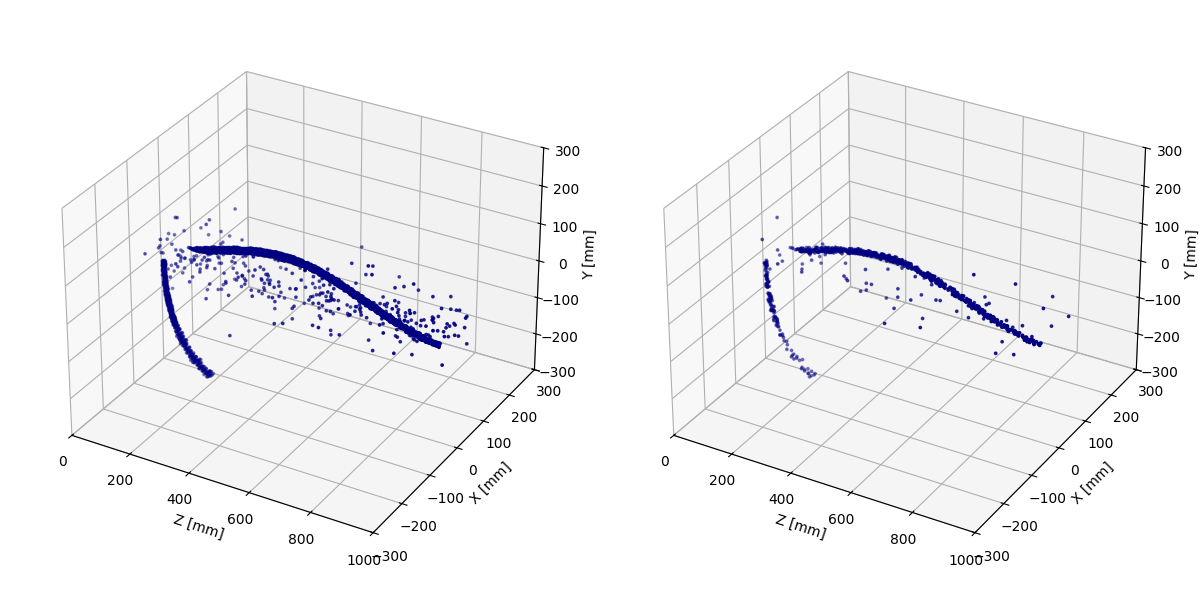

In [9]:
target_size = 800
dimension = 4
print(len(combined_data))
new_data = np.full((target_size, dimension), np.nan)
random_points = np.random.choice(len(combined_data), target_size, replace=False)

for r in range(len(random_points)):  #len(random_points)
    new_data[r] = combined_data[random_points[r]]



# ev_len = len(combined_data)
# new_data[:ev_len,:] = combined_data[:ev_len,:]
# need = target_size - len(combined_data)
# random_points = np.random.choice(ev_len, need, replace= True if need > ev_len else False)
# count = ev_len
# for r in random_points:
#     new_data[count] = combined_data[r]
#     if np.isnan(new_data[count, 0]):
#         print(f"NaN found at index {count}") #need to make sure no nans remain
#     count += 1


# fig = plt.figure(figsize=(6, 6), layout='constrained')
# ax = fig.add_subplot(111, projection='3d')
# ax.scatter(combined_data[:, 2], combined_data[:, 0], combined_data[:, 1], c="navy", s=3, label="combined")
# ax.scatter(new_data[:, 2], new_data[:, 0], new_data[:, 1], c="navy",s=3, label="resampled")

# ax.grid(True)
# ax.set_xlim3d(0, 1000)
# ax.set_xlabel("Z [mm]")
# ax.set_ylim3d(-300, 300)
# ax.set_ylabel("X [mm]")

# ax.set_zlim3d(-300, 300)
# ax.set_zlabel("Y [mm]")

# ax.dist=13
# ax.set_box_aspect(None, zoom=0.91)
# # ax.legend(markerscale=2,fontsize=10,loc='upper right', bbox_to_anchor=(1.0, 0.9))
# plt.show()

fig = plt.figure(figsize=(12, 6), layout='constrained')

# Left plot
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(combined_data[:, 2], combined_data[:, 0], combined_data[:, 1],
            c="navy", s=3)

# Right plot
ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(new_data[:, 2], new_data[:, 0], new_data[:, 1],
            c="navy", s=3)


for ax in [ax1, ax2]:
    ax.grid(True)
    ax.set_xlim3d(0, 1000)
    ax.set_xlabel("Z [mm]")
    ax.set_ylim3d(-300, 300)
    ax.set_ylabel("X [mm]")
    ax.set_zlim3d(-300, 300)
    ax.set_zlabel("Y [mm]")
    ax.dist = 13
    ax.set_box_aspect(None, zoom=0.91)

plt.show()

## Augmentation

90.4


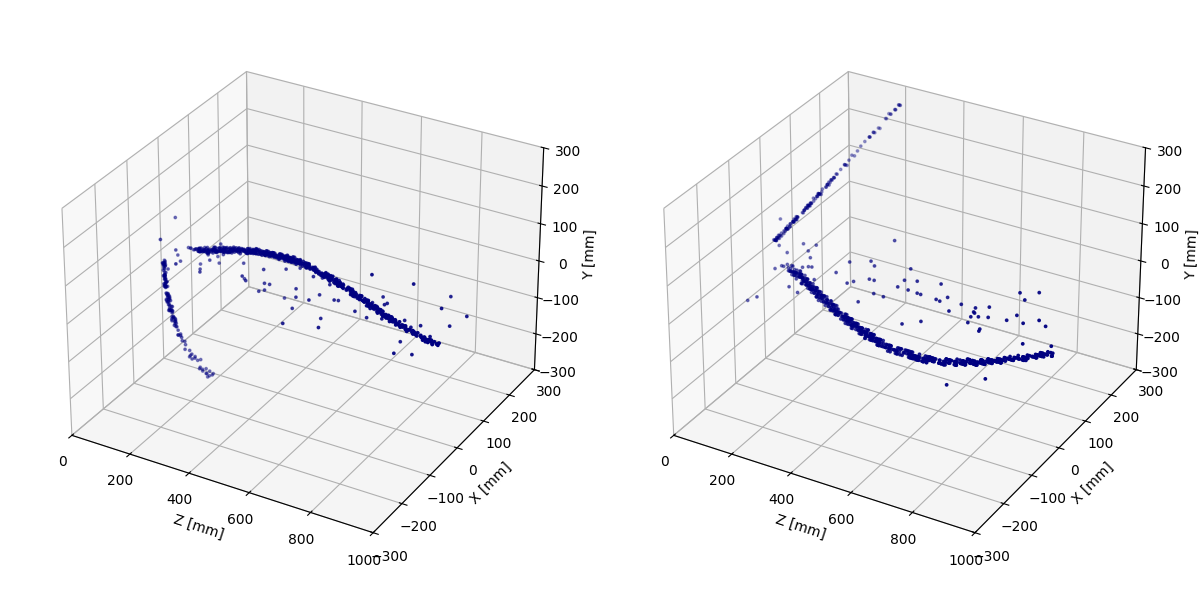

In [10]:
import numpy as np
import matplotlib.pyplot as plt


# ---- original normalized coordinates ----
orig = new_data.copy()
orig_x = orig[:, 0]
orig_y = orig[:, 1]
orig_z = (orig[:, 2])

# ---- rotated version (same logic as your augmentation) ----
theta = 90.4/57.2958#np.random.uniform(0, 2 * np.pi)
cos, sin = np.cos(theta), np.sin(theta)
print(theta*57.2958)
rot = new_data.copy()
x, y = rot[:, 0], rot[:, 1]
rot[:, 0] = cos * x - sin * y
rot[:, 1] = sin * x + cos * y

rot_x = rot[:, 0] 
rot_y = rot[:, 1] 
rot_z = rot[:, 2]

# ---- plotting (your exact style, adapted) ----
fig = plt.figure(figsize=(12, 6), layout='constrained')

# Left: original
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(orig_z, orig_x, orig_y, c="navy", s=3)

# Right: rotated
ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(rot_z, rot_x, rot_y, c="navy", s=3)

# ---- shared formatting ----
for ax in [ax1, ax2]:
    ax.grid(True)
    ax.set_xlim3d(0, 1000)
    ax.set_xlabel("Z [mm]")
    ax.set_ylim3d(-300, 300)
    ax.set_ylabel("X [mm]")
    ax.set_zlim3d(-300, 300)
    ax.set_zlabel("Y [mm]")
    ax.dist = 13
    ax.set_box_aspect(None, zoom=0.91)

plt.show()

## Scaling

Scaler min/max for dim 0: -93.80999743623657, 91.60023891331043
Scaler min/max for dim 1: -267.79135, 113.5480453538061
Scaler min/max for dim 2: 9.0, 996.6509577189049
Scaler min/max for dim 3: 0.0, 4095.0


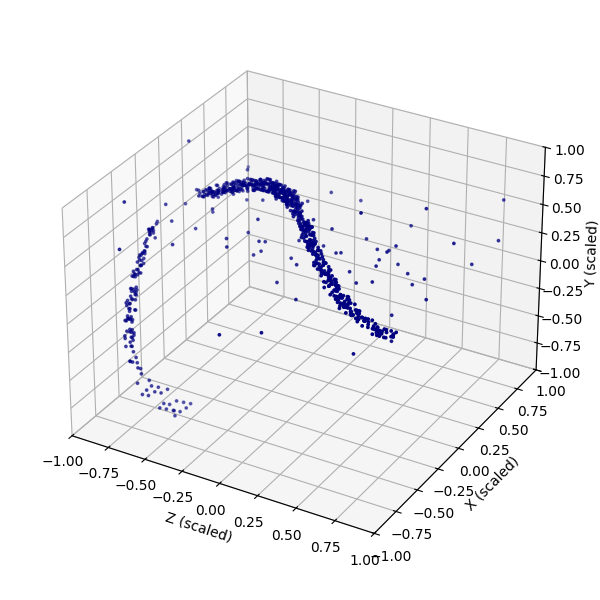

AttributeError: 'QuadMesh' object has no attribute 'do_3d_projection'

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# --- Your sampled data ---
target_size = 800
dimension = 4

# scaled_data = np.full((target_size, dimension), np.nan)
# random_points = np.random.choice(len(new_data), target_size, replace=False)

# for r in range(len(random_points)):
#     scaled_data[r] = new_data[random_points[r]]

# --- MinMax scaling to [-1, 1] per dimension ---
scaled_data = new_data.copy()

for n in range(dimension):
    col = scaled_data[:, n]

    # ignore NaNs if any
    valid_mask = ~np.isnan(col)
    col_valid = col[valid_mask]

    cmin = col_valid.min()
    cmax = col_valid.max()

    print(f"Scaler min/max for dim {n}: {cmin}, {cmax}")

    # MinMax → [-1, 1]
    scaled_col = 2 * (col_valid - cmin) / (cmax - cmin) - 1

    scaled_data[valid_mask, n] = scaled_col

# --- Plot (same format) ---
fig = plt.figure(figsize=(6, 6), layout='constrained')
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    scaled_data[:, 2],   # Z
    scaled_data[:, 0],   # X
    scaled_data[:, 1],   # Y
    s=3,
    c="navy"
)

ax.grid(True)

ax.set_xlim3d(-1, 1)
ax.set_xlabel("Z (scaled)")

ax.set_ylim3d(-1, 1)
ax.set_ylabel("X (scaled)")

ax.set_zlim3d(-1, 1)
ax.set_zlabel("Y (scaled)")

ax.dist = 13
ax.set_box_aspect(None, zoom=0.91)

# ax.legend(markerscale=2, fontsize=10, loc='upper right', bbox_to_anchor=(1.0, 0.9))

plt.show()

## confusion matrix

In [12]:
noise_0 = np.array([[1864,3,7,2,0],[76,1566,187,40,7],[80,27,1426,339,4],[18,78,569,1017,195],[0,108,68,382,1318]])
noise_1 = np.array([[1795,26,52,2,1],[54,1410,206,105,101],[103,63,1227,471,12],[21,102,452,1041,261],[1,113,49,400,1313]])
noise_5 = np.array([[1702,24,141,10,0],[61,1226,200,178,211],[88,20,1184,562,22],[17,40,422,1131,266],[0,92,55,429,1300]])
noise_10 = np.array([[1485,109,258,23,1],[23,800,138,284,631],[45,25,860,889,57],[6,15,198,1245,413],[0,22,16,347,1491]])

In [13]:

cf_matrix = noise_0

group_counts = ["{0:0.0f}".format(value) for value in
                cf_matrix.flatten()]
# group_percentages = ["{0:.2%}".format(value) for value in
#                  cf_matrix.flatten()/np.sum(cf_matrix)]
labels = [f"{v1}" for v1 in group_counts]
labels = np.asarray(labels).reshape(5,5)
class_names = ["Class 0", "Class 1", "Class 2", "Class 3", "Class 4"]  # Change to your labels

svm = sns.heatmap(cf_matrix, annot=labels, fmt='', cmap='RdPu', cbar=False, square=True,)
svm.set_xlabel("Predicted Labels")
svm.set_ylabel("True Labels")
svm.set_xticklabels(class_names)
svm.set_yticklabels(class_names, rotation=0)

plt.savefig("/Users/pranjalsingh/Desktop/research_space_spyral/Spyral_1.0/confusion_matrix.png")

/Users/pranjalsingh/Desktop/research_space_spyral/Spyral_1.0/.venv/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.draw()


AttributeError: 'QuadMesh' object has no attribute 'do_3d_projection'

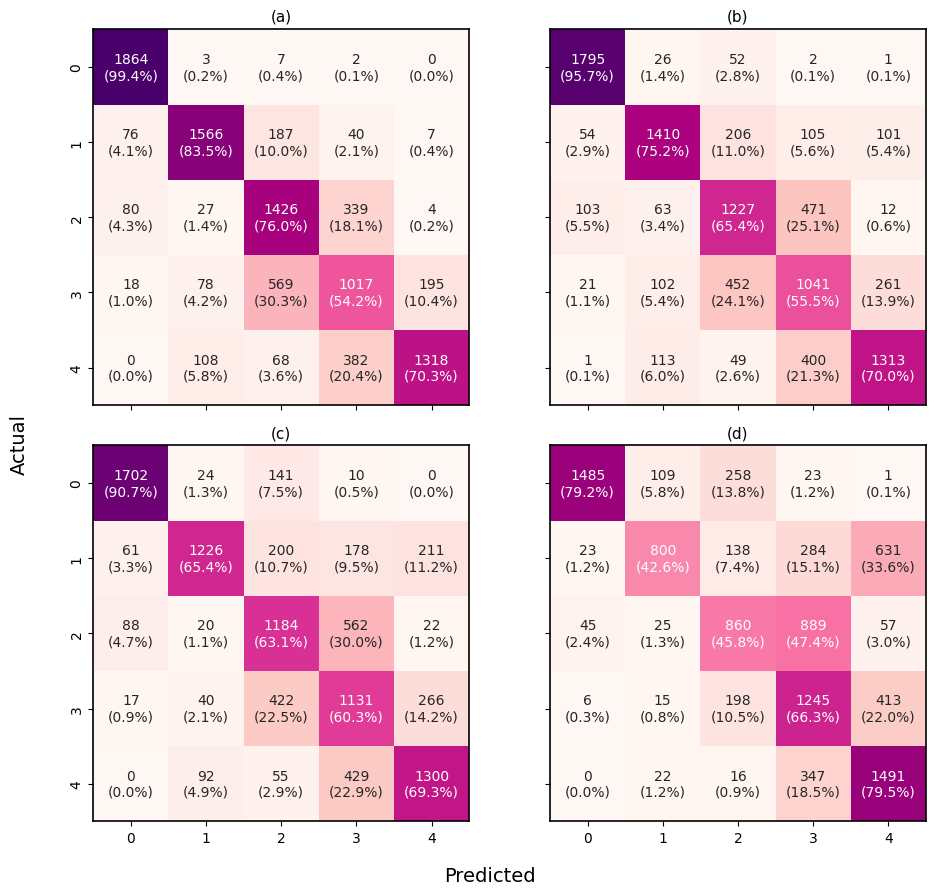

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Data
# -----------------------------
noise_0 = np.array([[1864,3,7,2,0],[76,1566,187,40,7],[80,27,1426,339,4],[18,78,569,1017,195],[0,108,68,382,1318]])
noise_1 = np.array([[1795,26,52,2,1],[54,1410,206,105,101],[103,63,1227,471,12],[21,102,452,1041,261],[1,113,49,400,1313]])
noise_5 = np.array([[1702,24,141,10,0],[61,1226,200,178,211],[88,20,1184,562,22],[17,40,422,1131,266],[0,92,55,429,1300]])
noise_10 = np.array([[1485,109,258,23,1],[23,800,138,284,631],[45,25,860,889,57],[6,15,198,1245,413],[0,22,16,347,1491]])

# noise_0_percent = 

matrices = [noise_0, noise_1, noise_5, noise_10]
titles = ["a", "b", "c", "d"]

# -----------------------------
# Shared color scale
# -----------------------------
vmin = min(m.min() for m in matrices)
vmax = max(m.max() for m in matrices)

# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(10, 9), sharex=True, sharey=True)

for ax, matrix, title in zip(axes.flatten(), matrices, titles):
    
    
    percentages = np.array([(val/np.sum(val)) for val in matrix])
    # print(percentages)
    # percentages_labels = np.array(["{:.2f}".format(val) for val in percentages.flatten()]).reshape(5, 5)
    labels = np.array([f"{val:0d}\n({percent:.1%})" for val,percent in zip(matrix.flatten(),percentages.flatten())]).reshape(5, 5)
    
    sns.heatmap(
        matrix,
        annot=labels,
        fmt='',
        cmap='RdPu',
        cbar=False,
        square=True,
        vmin=vmin,
        vmax=vmax,
        xticklabels=True,
        yticklabels=True,
        ax=ax,
        linecolor="black"
    )
    
    ax.set_title(f"({title})", fontsize=11)

    # -----------------------------
    # Add clean box around each plot
    # -----------------------------
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.2)


fig.supxlabel("Predicted",fontsize=14)
fig.supylabel("Actual",fontsize=14)

plt.tight_layout()
plt.savefig(
    "/Users/pranjalsingh/Desktop/research_space_spyral/Spyral_1.0/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


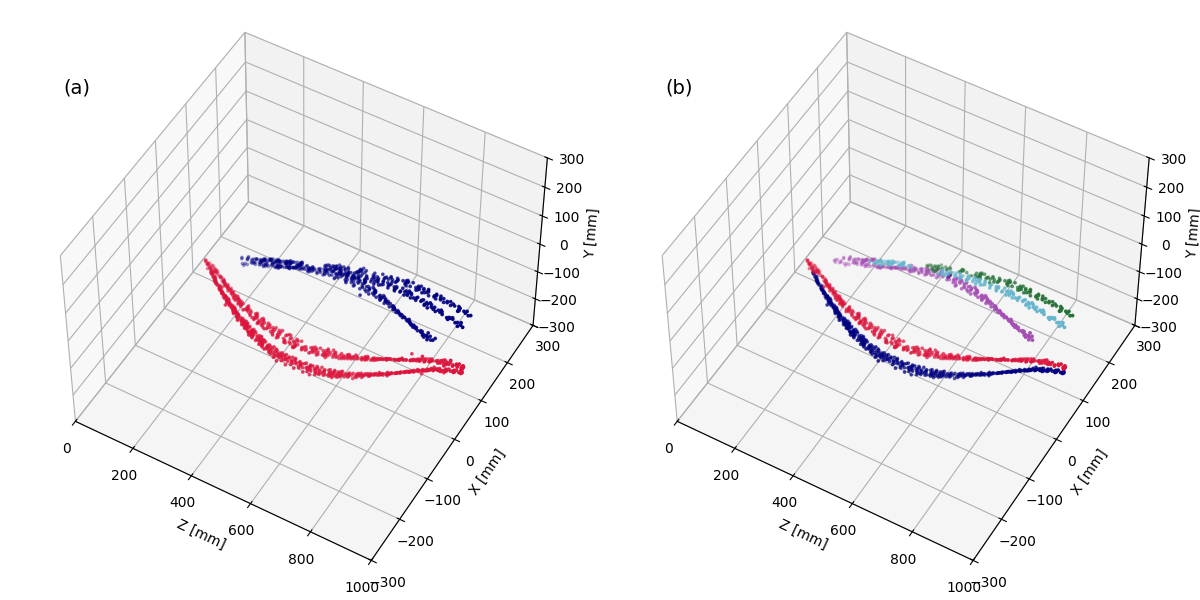

In [60]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

palette = [
    "#DC143C","#000080",
    "#A54FB4", "#64B5CD",
    "#257137", "#612890"  # last = 6+
]

run = 104

before_opt_path = (
    f"/Volumes/researchEXT/O16/all_analysis_spyralv1.0/"
    f"uplotimized_all_original_data_tripclust/Cluster/run_{run:04d}.h5"
)

after_opt_path = (
    f"/Volumes/researchEXT/O16/all_analysis_spyralv1.0/"
    f"corrected_ml_08042026_tripclust/Cluster/run_{run:04d}.h5"
)

event = 1945978


def load_event_clusters(h5_path, event):
    """
    Returns a list of cluster arrays for one event.
    Each cluster array is assumed to contain columns [x, y, z].
    """
    clusters = []

    with h5py.File(h5_path, "r") as f:
        event_group = f["cluster"][f"event_{event}"]

        for cname in event_group:
            data = np.array(event_group[cname]["cloud"])

            # Skip empty clusters
            if len(data) == 0:
                continue

            clusters.append(data)

    return clusters


before_clusters = load_event_clusters(before_opt_path, event)
after_clusters = load_event_clusters(after_opt_path, event)

fig = plt.figure(figsize=(12, 6), layout='constrained')

# -----------------------------------
# BEFORE
# -----------------------------------
ax1 = fig.add_subplot(121, projection='3d')

for i, cluster in enumerate(before_clusters):

    color = palette[i] if i < len(palette) else palette[-1]

    # Assuming columns are [x, y, z]
    x = cluster[:, 0]
    y = cluster[:, 1]
    z = cluster[:, 2]

    ax1.scatter(
        z, x, y,
        color=color,
        s=3,
        label=f"Cluster {i}"
    )



# -----------------------------------
# AFTER
# -----------------------------------
ax2 = fig.add_subplot(122, projection='3d')

for i, cluster in enumerate(after_clusters):

    color = palette[i] if i < len(palette) else palette[-1]

    x = cluster[:, 0]
    y = cluster[:, 1]
    z = cluster[:, 2]

    ax2.scatter(
        z, x, y,
        color=color,
        s=3,
        label=f"Cluster {i}"
    )

labels=["a","b"]

# -----------------------------------
# Common formatting
# -----------------------------------
for i,ax in enumerate([ax1, ax2]):
    ax.grid(True)

    ax.set_xlim3d(0, 1000)
    ax.set_xlabel("Z [mm]")

    ax.set_ylim3d(-300, 300)
    ax.set_ylabel("X [mm]")

    ax.set_zlim3d(-300, 300)
    ax.set_zlabel("Y [mm]")

    ax.dist = 13
    ax.text2D(0.1, 0.85, f"({labels[i]})", transform=ax.transAxes, fontsize=14)
    ax.set_box_aspect(None, zoom=0.91)
    ax.view_init(elev=50)
plt.show()

[14.725587462676748, 12.080783519313885, 10.572623767826755, 9.67991509548207, 9.177124390733264, 8.862583055388738, 8.664824504149584, 8.541281967646123, 8.480172825739807, 8.436791300591869, 8.402245920573012, 8.385026310530447, 8.35069288801885, 8.35069288801885, 8.342131520856787, 8.333578931051129, 8.325035109603077, 8.325035109603077, 8.325035109603077, 8.325035109603077, 8.325035109603077, 8.316500047523062, 8.316500047523062, 8.316500047523062, 8.316500047523062, 8.316500047523062, 8.316500047523062, 8.299456165554949, 8.307973735830736, 8.307973735830736, 8.299456165554949, 8.307973735830736, 8.307973735830736, 8.299456165554949, 8.299456165554949, 8.307973735830736, 8.290947327733754, 8.299456165554949, 8.307973735830736, 8.299456165554949, 8.290947327733754, 8.282447213414391, 8.282447213414391, 8.27395581365328]


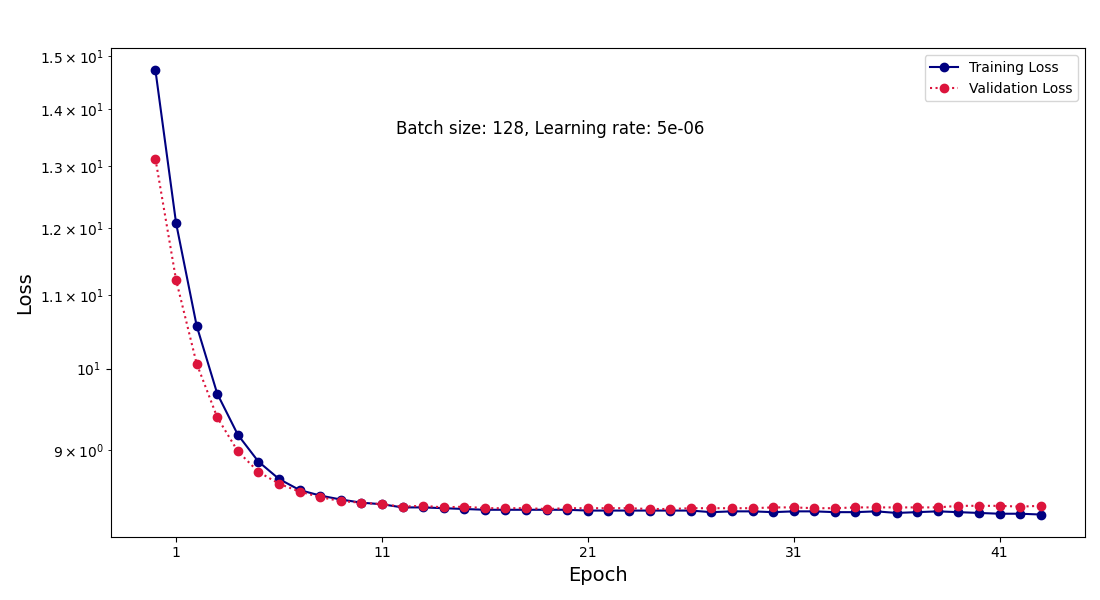

In [37]:
df = pd.read_csv("/Users/pranjalsingh/Desktop/plot-data.csv")
df_2 = pd.read_csv("/Users/pranjalsingh/Desktop/plot-data-2.csv")
train_loss = df[" y"].to_list()
epoch = df_2["x"].to_list()
val_loss = df_2[" y"].to_list()

print(train_loss)
# df.columns
plt.figure(figsize=(11, 6), dpi=100)
plt.plot(train_loss, 'o-',color="navy", label='Training Loss')
plt.plot(val_loss[:-1], 'o:', color='crimson', label='Validation Loss')
plt.legend(loc='best')
# plt.title('Learning Curve')
plt.suptitle(f"Batch size: {128}, Learning rate: {5e-06}", y=0.8)
plt.xlabel('Epoch',fontsize=14)
plt.ylabel('Loss',fontsize=14)
plt.xticks([int(i) for i in epoch[:-1:10]])
# plt.yticks(train_loss_2[::10])
plt.yscale('log')
plt.tight_layout()
plt.show()


